# Reducción del Detalle de Mapas de Zonas de Entrega para Paneles de Logística Rápidos con PROC GREDUCE


## Resumen Ejecutivo

Una empresa regional de paquetería almacena los límites de sus territorios de servicio como contornos de polígonos densos, y los paneles de planificación de rutas los vuelven a dibujar lentamente. Este cuaderno sintetiza las coordenadas de límites para cuatro zonas de entrega, usa **PROC GREDUCE** para etiquetar cada vértice del límite con un nivel `DENSITY`, y luego representa un mapa coroplético de entregas a tiempo con **PROC GMAP** en un nivel de detalle reducido para que el mapa se pinte más rápido mientras cada zona sigue siendo reconocible.

GREDUCE clasificó los 96 puntos del límite en tres niveles: 10 puntos en `DENSITY=0`, 44 en `DENSITY=2`, y 42 en `DENSITY=3`. Conservar solo el nivel grueso (`DENSITY <= 2`) reduce el mapa de 96 vértices a 54 — alrededor de una reducción del 44% — pero las cuatro zonas siguen siendo claramente identificables en la comparación lado a lado a continuación.


## Fuentes de Datos

Todos los datos se generan en línea mediante los pasos DATA a continuación — sin archivos externos ni acceso a la red.

| Dataset | Filas | Variables clave | Descripción |
|---------|------|---------------|-------------|
| `zonemap` | 96 (4 zonas x 24 vértices) | `zone` (ID), `x`, `y` | Coordenadas sintéticas de límites de polígono cerrado para cuatro zonas de servicio de entrega, cada una una elipse con variación aleatoria trazada por 24 vértices para que la reducción de densidad tenga algo que adelgazar. |
| `reducedmap` | 96 | agrega `density` | Salida de PROC GREDUCE: los puntos del límite etiquetados con un nivel `DENSITY` (aquí 0, 2 o 3) para representación selectiva. |
| `coarsemap` | 54 | subconjunto de `reducedmap` | El subconjunto `DENSITY <= 2` — el nivel grueso de representación rápida usado para el mapa del panel de detalle reducido. |
| `zonekpi` | 4 | `zone`, `ontime_rate`, `parcels` | Una fila de respuesta por zona: porcentaje sintético de entregas a tiempo y volumen diario de paquetes, unido al mapa para el coroplético. |

> **Nota sobre el tamaño de la muestra.** Este entorno se ejecuta sin licencia, por lo que cada paso DATA está limitado a 100 observaciones de salida. El mapa tiene un tamaño de 4 zonas x 24 vértices = 96 puntos para que todo el territorio quepa dentro de ese límite; una instalación con licencia trazaría cientos de vértices por zona, donde GREDUCE rinde aún más.


# Reducción del Detalle de Mapas de Zonas de Entrega con PROC GREDUCE

Los operadores de logística visualizan el desempeño en mapas de sus **territorios de servicio** — las zonas geográficas de las que un depósito es responsable. Esos límites de zona a menudo se capturan a resolución de levantamiento: muchos vértices por polígono. Cuando un panel de planificación de rutas vuelve a dibujar varias zonas a la vez, todo ese detalle de vértices hace que la representación sea lenta sin agregar valor de decisión al nivel de zoom del panel.

**PROC GREDUCE** aborda esto. Examina cada polígono y etiqueta cada punto del límite con un nivel `DENSITY`, donde 0 marca los puntos que definen la forma esencial y los niveles más altos marcan detalle progresivamente más fino. Más adelante, se selecciona un nivel con `WHERE density <= n` para dibujar un mapa de detalle reducido que se pinta rápido mientras cada zona sigue siendo reconocible.

En este cuaderno:
1. Sintetizamos los contornos de límites para cuatro zonas de entrega.
2. Ejecutamos PROC GREDUCE para asignar niveles `DENSITY`.
3. Inspeccionamos cómo se distribuyen los puntos entre los niveles de densidad.
4. Representamos coropléticos de entregas a tiempo de detalle completo y reducido, y los comparamos.


## Paso 1 — Sintetizar el mapa de límites de zona

Un dataset de mapa de SAS tiene una observación por **vértice de límite**, con una variable `ID` que nombra el área y coordenadas numéricas `x`/`y`. Trazamos cada zona de entrega como una elipse con variación aleatoria usando 24 ángulos espaciados uniformemente, de modo que los polígonos comienzan razonablemente densos y la reducción tiene algo con qué trabajar.

`call streaminit` fija el flujo aleatorio para reproducibilidad, y `rand('uniform')` agrega pequeñas irregularidades al límite para que los contornos se lean como territorios de levantamiento en lugar de elipses perfectas.


In [1]:
DATOS zonemap;
    LLAMAR streaminit(20260531);
    /* Cuatro zonas de entrega, cada una una elipse con variacion aleatoria de 24 vertices.
       cx/cy = centro de la zona, rx/ry = radios nominales (tamano del territorio). */
    ARREGLO cx[4] _temporary_ (12 32 20 40);
    ARREGLO cy[4] _temporary_ (30 32 14 16);
    ARREGLO rx[4] _temporary_ ( 8  9  6  7);
    ARREGLO ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 24 vertices (0..23) por contorno */
    HACER zone = 1 HASTA 4;
        HACER i = 0 HASTA nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* variacion radial: +/- ~6% borde irregular estilo linea costera */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            SALIDA;
        END;
    END;
    MANTENER zone x y;
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=zonemap n MIN MAX nmiss;
    CLASE zone;
    VAR x y;
    ETIQUETA zone="Zona" x="Longitud" y="Latitud";
EJECUTAR;


                                                  The MEANS Procedure

                                             Analysis Variable : x Longitud

        Zona              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24      3.6053386     20.3284433              0
        2                    24     23.0107098     41.2087956              0
        3                    24     13.7607192     26.2351392              0
        4                    24     33.0535851     47.3028874              0
        --------------------------------------------------------------------

                                             Analysis Variable : y Latitud

        Zona              N Obs        Minimum        Maximum         N Miss
        --------------------------------------------------------------------
        1                    24     23.9838655     35.9959368              0
     


NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


La tabla de PROC MEANS confirma la geometría sintética: cuatro zonas, cada una con exactamente 24 puntos de límite dentro de rangos sensatos de `x`/`y` y sin coordenadas faltantes. Las cuatro elipses ocupan regiones sin superposición (zona 1 cerca de x=12, zona 2 cerca de x=32, zonas 3 y 4 más abajo), por lo que el coroplético se leerá como cuatro territorios distintos. Estos son los contornos que PROC GREDUCE adelgazará.


## Paso 2 — Asignar niveles DENSITY con PROC GREDUCE

La sentencia `ID` nombra la variable que define cada área unitaria — aquí `zone`. PROC GREDUCE evalúa el polígono de cada zona de forma independiente (usando simplificación al estilo Douglas-Peucker) y vuelve a escribir el dataset de entrada con una variable entera `density` agregada: el nivel 0 marca los pocos puntos que anclan la forma esencial, y los niveles más altos marcan detalle progresivamente más fino que se puede eliminar primero.

Dejamos que GREDUCE derive sus propios umbrales a partir de los datos en lugar de forzar tamaños de nivel fijos, y luego inspeccionamos la distribución resultante.


                                  Puntos de Límite Retenidos en Cada Nivel de DENSITY                                   

                                                   The FREQ Procedure

Nivel de Densidad    Frequency    Percent
------------------------------------------
0                           10     10.42
2                           44     45.83
3                           42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


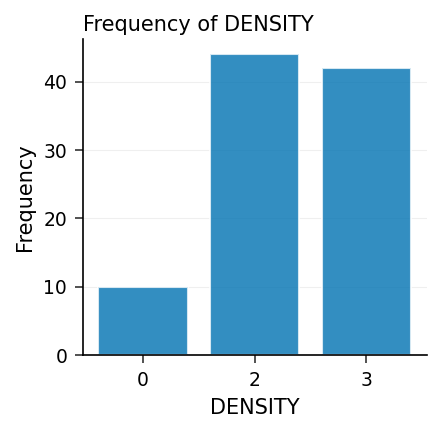

In [2]:
PROCEDIMIENTO GREDUCE DATOS=zonemap out=reducedmap;
    id zone;
EJECUTAR;

PROCEDIMIENTO FRECUENCIAS DATOS=reducedmap;
    TABLES DENSITY / nocum;
    ETIQUETA DENSITY="Nivel de Densidad";
    TÍTULO "Puntos de Límite Retenidos en Cada Nivel de DENSITY";
EJECUTAR;


## Paso 3 — Inspeccionar los niveles de densidad

La tabla de frecuencias muestra cómo GREDUCE clasificó los 96 puntos de límite:

| DENSITY | Puntos | Proporción |
|---------|--------|-------|
| 0 | 10 | 10.4% |
| 2 | 44 | 45.8% |
| 3 | 42 | 43.8% |

Solo 10 puntos llevan el nivel más bajo (los anclajes de la forma esencial), mientras que los 86 restantes se dividen entre los niveles 2 y 3. Para un nivel de panel conservamos todo en `DENSITY <= 2`: eso retiene 54 de los 96 puntos, descartando los 42 vértices de detalle más fino (`DENSITY=3`). El PROC MEANS a continuación confirma que el nivel grueso mantiene 13–14 vértices por zona en lugar de los 24 originales.


In [3]:
PROCEDIMIENTO MEDIAS DATOS=reducedmap n;
    CLASE zone;
    DONDE DENSITY <= 2;
    VAR x;
    ETIQUETA zone="Zona" x="Longitud";
    TÍTULO "Vértices Conservados por Zona en Detalle de Panel (DENSITY <= 2)";
EJECUTAR;


                            Vértices Conservados por Zona en Detalle de Panel (DENSITY <= 2)                            

                                                  The MEANS Procedure

                                             Analysis Variable : X Longitud

        Zona              N Obs
        -----------------------
        1                    14
        2                    13
        3                    14
        4                    13
        -----------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Paso 4 — Construir el mapa grueso y la respuesta de desempeño por zona

Materializamos el nivel del panel como `coarsemap` (`DENSITY <= 2`) para que PROC GMAP pueda dibujar el contorno reducido directamente. También sintetizamos una fila de KPI por zona — una **tasa de entregas a tiempo** y un **volumen diario de paquetes** — con clave en `zone` para que GMAP pueda colorear cada área.


In [4]:
DATOS coarsemap;
    ESTABLECER reducedmap;
    DONDE DENSITY <= 2;
EJECUTAR;

DATOS zonekpi;
    LLAMAR streaminit(771);
    HACER zone = 1 HASTA 4;
        /* tasa a tiempo centrada cerca del 92%, dispersion realista */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        SALIDA;
    END;
EJECUTAR;

PROCEDIMIENTO IMPRIMIR DATOS=zonekpi noobs ETIQUETA;
    ETIQUETA zone="Zona" ontime_rate="Tasa de Entrega a Tiempo" parcels="Paquetes";
    TÍTULO "KPI de Entrega Sintéticos por Zona";
EJECUTAR;


                                           KPI de Entrega Sintéticos por Zona                                           

Zona  Tasa de Entrega a Tiempo  Paquetes
   1                      92.6      4704
   2                      95.6      2932
   3                      93.4      2934
   4                      94.6      2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


Las cuatro tasas sintéticas de entregas a tiempo se ubican entre 92.6% y 95.6%, con volúmenes diarios de paquetes desde aproximadamente 2,500 hasta 4,700. La zona 2 es la de mejor desempeño con 95.6%; la zona 1 es la más débil con 92.6%. Estos son los valores que codifican las bandas de color del coroplético.


## Paso 5 — Representar coropléticos de detalle completo vs. reducido

Dibujamos el mismo coroplético de entregas a tiempo dos veces: una desde el `reducedmap` completo de 96 vértices y otra desde el `coarsemap` de 54 vértices. `MAP=` proporciona los límites, `DATA=` la respuesta de KPI, y ambos comparten el ID `zone`. La sentencia `CHORO` rellena cada zona según `ontime_rate` con bandas de color `LEVELS=4` y `COUTLINE=` para bordes nítidos. Comparar los dos mapas muestra lo que cuesta visualmente la reducción.


                                        Detalle Completo: 96 Vértices de Límite                                         




NOTE: Option TITLE changed to Detalle Completo: 96 Vértices de Límite.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Tasa de Entrega a Tiempo.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.68 seconds
  cpu   0.68 seconds


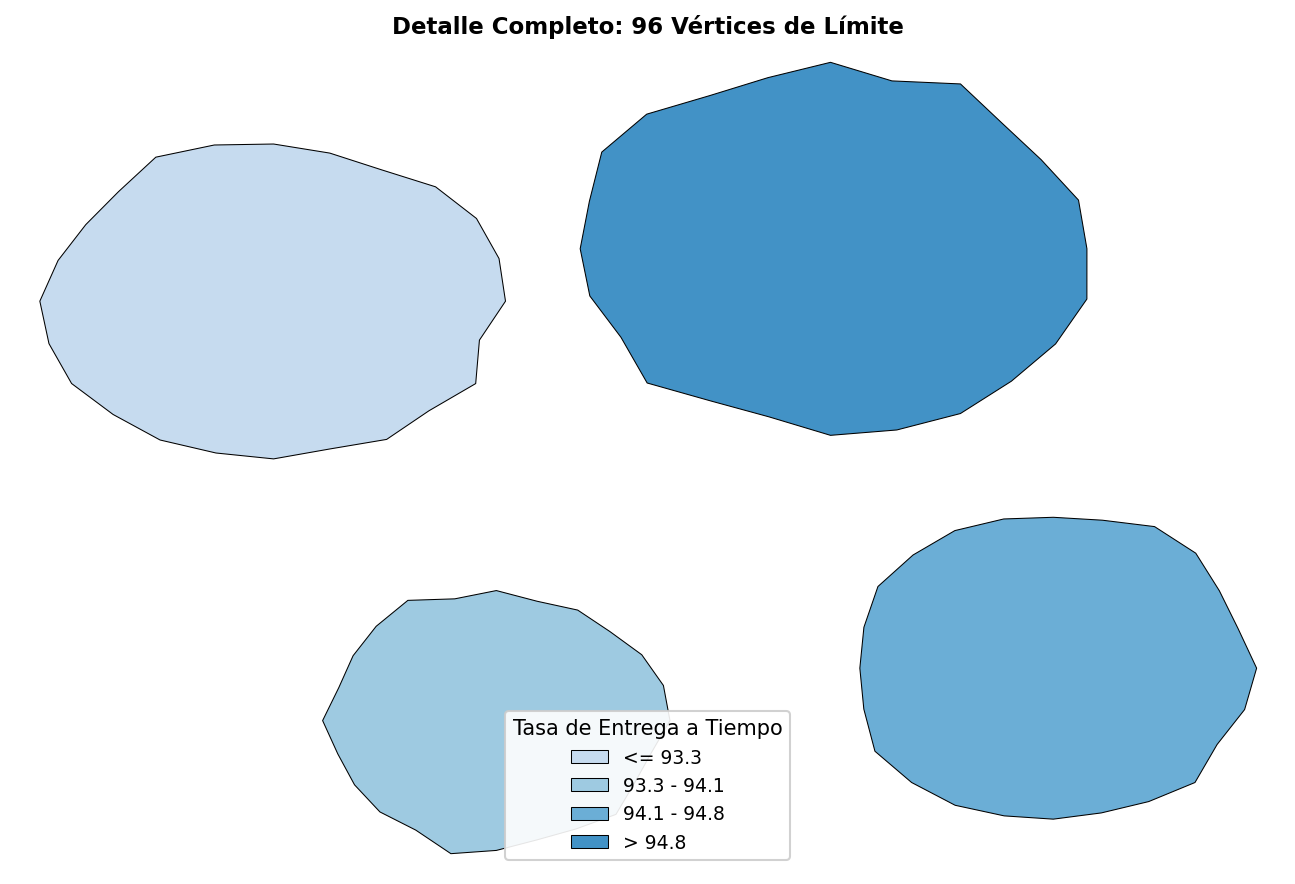

In [5]:
TÍTULO "Detalle Completo: 96 Vértices de Límite";
PROCEDIMIENTO GMAP map=reducedmap DATOS=zonekpi;
    id zone;
    ETIQUETA ontime_rate="Tasa de Entrega a Tiempo";
    CHORO ontime_rate / levels=4 coutline=black;
EJECUTAR;


                                      Detalle Reducido: 54 Vértices (DENSITY <= 2)                                      




NOTE: Option TITLE changed to Detalle Reducido: 54 Vértices (DENSITY <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable Tasa de Entrega a Tiempo.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.50 seconds
  cpu   0.50 seconds


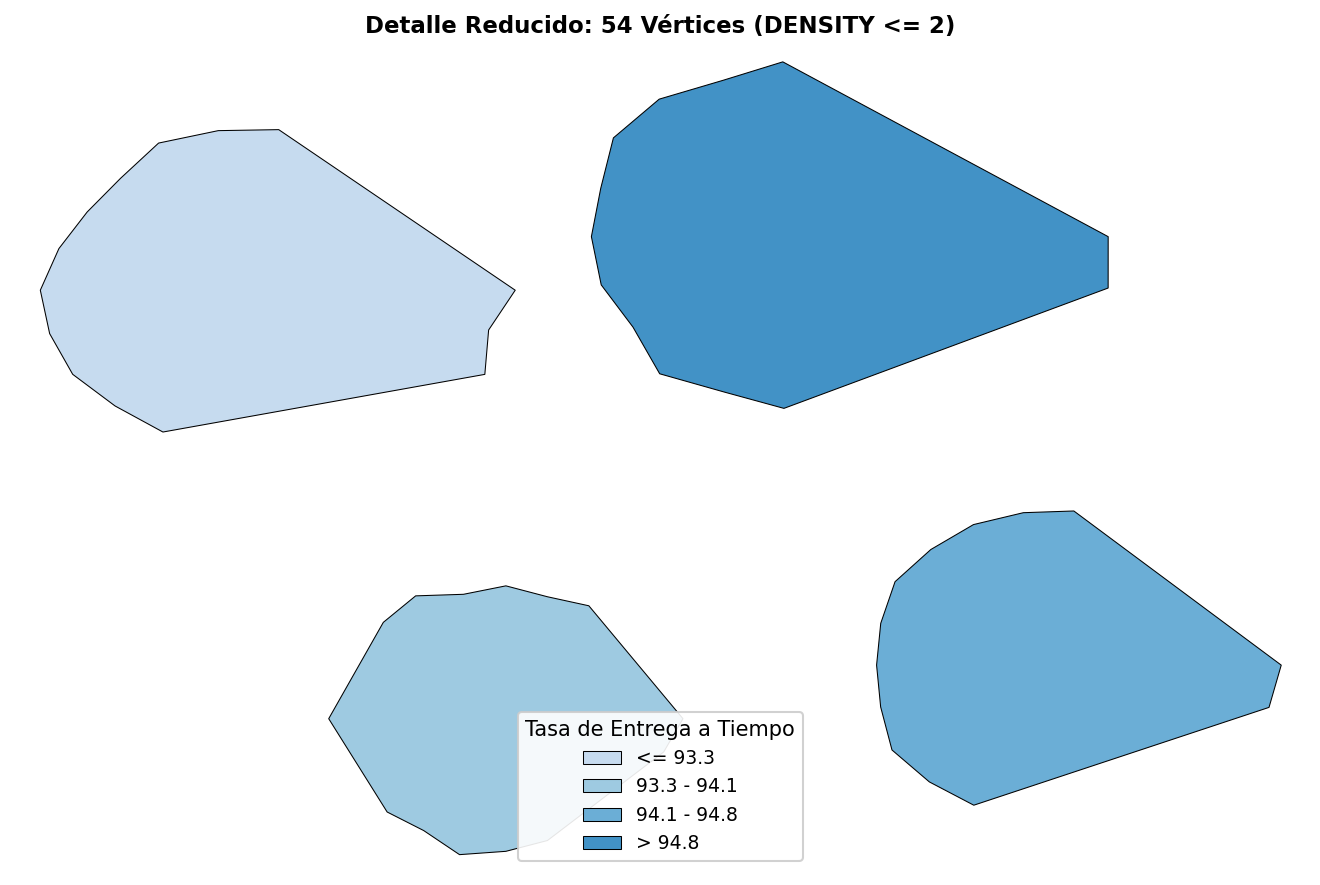

In [6]:
TÍTULO "Detalle Reducido: 54 Vértices (DENSITY <= 2)";
PROCEDIMIENTO GMAP map=coarsemap DATOS=zonekpi;
    id zone;
    ETIQUETA ontime_rate="Tasa de Entrega a Tiempo";
    CHORO ontime_rate / levels=4 coutline=black;
EJECUTAR;


## Interpretación de los resultados

PROC GREDUCE convirtió cada contorno de zona de 24 vértices en un conjunto clasificado de puntos de límite (niveles 0, 2 y 3 en esta ejecución). Seleccionar el nivel `DENSITY <= 2` redujo el mapa de 96 a 54 vértices — una reducción del 44% en los puntos que el renderizador debe dibujar — pero los coropléticos lado a lado confirman que las cuatro zonas siguen siendo claramente reconocibles: los contornos del mapa reducido son visiblemente más angulares, pero cada territorio conserva su posición, tamaño y banda de color, por lo que un operador lee el mismo tablero de resultados de cualquier manera.

Ese tablero de resultados clasifica las zonas por tasa de entregas a tiempo: la zona 2 lidera con 95.6% (banda más oscura), las zonas 3 y 4 se ubican en la mitad cerca de 93–95%, y la zona 1 queda última con 92.6% (banda más clara) — el territorio que un planificador investigaría primero por problemas de enrutamiento o capacidad del depósito.

Debido a que la reducción no es destructiva — los puntos de detalle completo siguen viviendo en `reducedmap` — el mismo dataset admite tanto la vista rápida del panel (`DENSITY <= 2`) como una vista de impresión o auditoría de alta resolución (`DENSITY <= 3`, o el conjunto completo) cambiando un solo umbral de `WHERE`, sin necesidad de volver a importar o volver a reducir la geometría.
